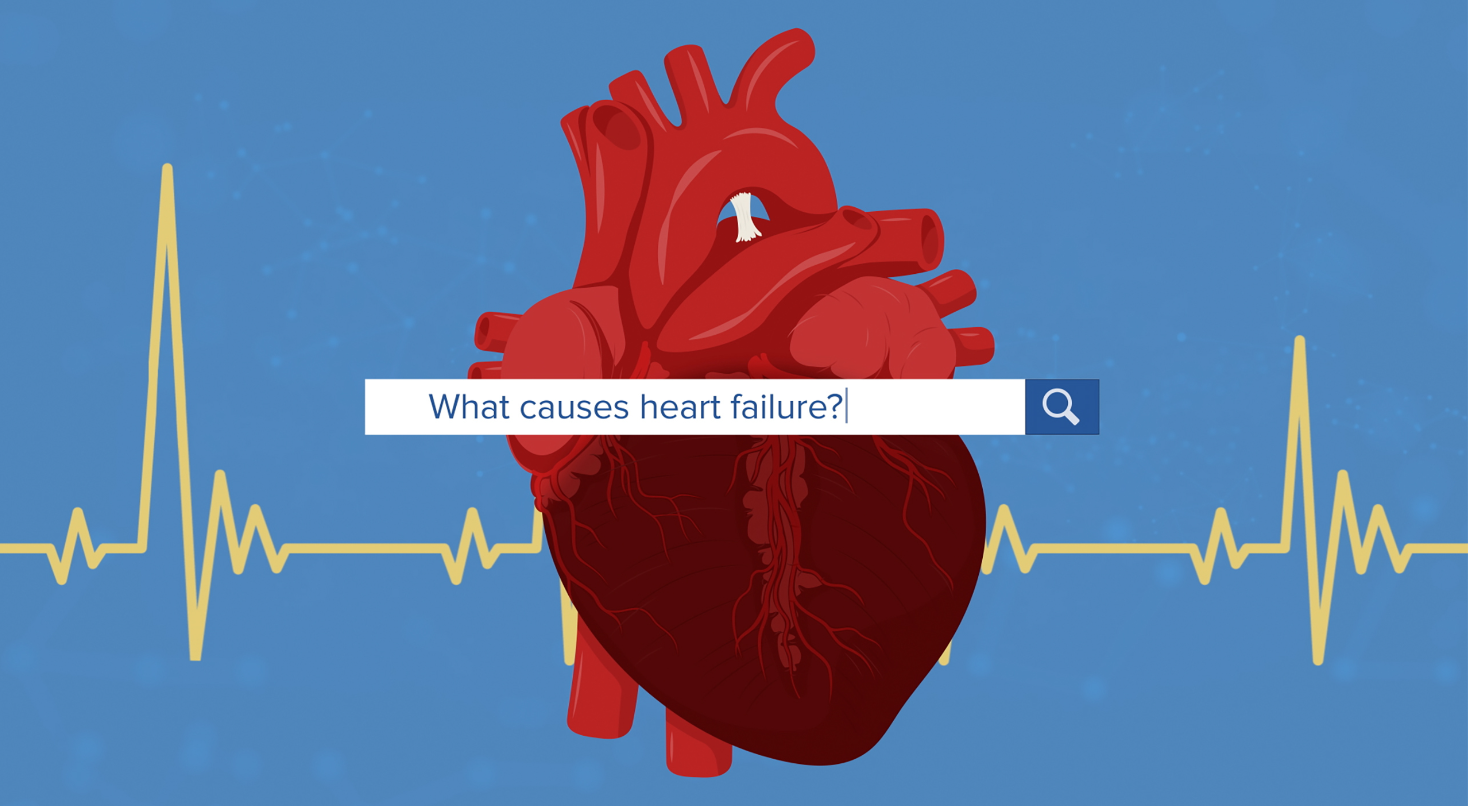

<center>
    <figcaption itemprop="Image Taken From Here"><a href="https://www.yalemedicine.org/news/what-causes-heart-failure">Heart Attack</a></figcaption>
</center>


**📜 Table Of Contents:**
* [EDA (Exploratory Data Analysis)](#section-one)
* [VISUALIZATION](#section-two)
* [FEATURE ENGINEERING](#section-three)
    - [Missing Values](#section-four)
    - [Outlier Detection & Handling](#section-five)
    - [Feature Extraction](#section-six)
    - [Encoding & Scaling](#section-seven)
* [MODEL](#section-eight)
* [FOR FURTHER](#section-nine)

---

1. **Age** : Age of the patient
2. **Sex** : Sex of the patient
3. **exang**: exercise induced angina
    - 1: yes
    - 0: no
4. **ca**: number of major vessels (0-3)
5. **cp** : Chest Pain type chest pain type
    - Value 1: typical angina
    - Value 2: atypical angina
    - Value 3: non-anginal pain
    - Value 4: asymptomatic trtbps : resting blood pressure (in mm Hg)
6. **chol** : cholestoral in mg/dl fetched via BMI sensor
7. **fbs** : fasting blood sugar > 120 mg/dl
    - 1: true
    - 0: false)
8. **rest_ecg** : resting electrocardiographic results
    - Value 0: normal
    - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria thalach : maximum heart rate achieved
9. **thalachh**: Maximum heart rate achieved during a stress test exng: Exercise induced angina
  - 0: no
  - 1: yes
10. **oldpeak:** ST depression induced by exercise relative to rest (unit -> depression)
11. **slp:** Slope of the peak exercise ST segment (
    - 0: Upsloping
    - 1: Flat
    - 2: Downsloping
12. **caa:** Number of major vessels (0-4) colored by fluoroscopy thall: Thalium stress test result
  - 0: Normal
  - 1: Fixed defect
  - 2: Reversible defect
  - 3: Not described
13. **target** :
    - 0: less chance of heart attack
    - 1: more chance of heart attack

# **Importing Required Libraries**

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format',  '{:.2f}'.format)

In [51]:
df = pd.read_csv("data\heart.csv")
df_copy = df.copy()
df_copy.head()

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\3129002050.py:1: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv("data\heart.csv")


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1


<a id="section-one"></a>
# **EDA**

In [52]:
df_copy.shape

(303, 14)

In [53]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [54]:
print(f'Shape     : {df_copy.shape}\n'
      f'Size      : {df_copy.size}\n'
      f'Dimension : {df_copy.ndim}')

Shape     : (303, 14)
Size      : 4242
Dimension : 2


In [55]:
df_copy.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [56]:
df_copy.duplicated().sum()

np.int64(1)

In [57]:
df_copy.loc[df_copy.duplicated(keep=False), :]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
163,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1


In [58]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.00,54.37,9.08,29.00,47.50,55.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,0.97,1.03,0.00,0.00,1.00,2.00,3.00
trtbps,303.00,131.62,17.54,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.26,51.83,126.00,211.00,240.00,274.50,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.53,0.53,0.00,0.00,1.00,1.00,2.00
thalachh,303.00,149.65,22.91,71.00,133.50,153.00,166.00,202.00
exng,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [59]:
df.nunique()

age          41
sex           2
cp            4
trtbps       49
chol        152
fbs           2
restecg       3
thalachh     91
exng          2
oldpeak      40
slp           3
caa           5
thall         4
output        2
dtype: int64

In [60]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall', 'output']
num_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

<a id="section-two"></a>
# **VISUALIZATION**

C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\472036015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_copy,


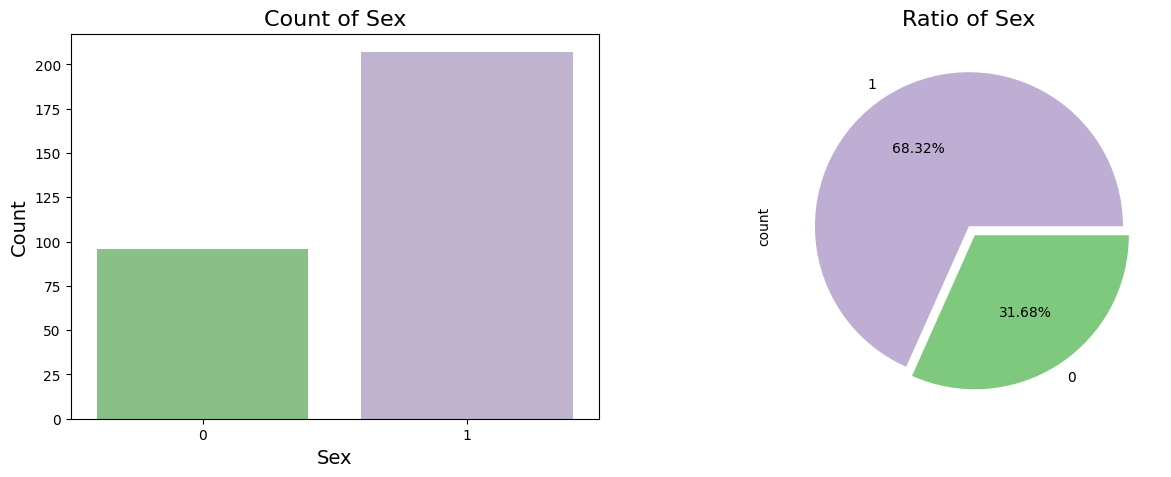

In [61]:
palette_color = sns.color_palette('Accent')

fig, axs = plt.subplots(1,2, figsize = (15, 5))
ax = sns.countplot(data=df_copy,
                   x=df_copy['sex'],
                   ax = axs[0],
                   palette='Accent');

ax.set_xlabel('Sex', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
axs[0].set_title("Count of Sex", fontsize=16)

ax2 = df_copy['sex'].value_counts().plot.pie(explode=[0,0.07],
                                             colors=[palette_color[1], palette_color[0]],
                                             ax = axs[1],
                                             autopct='%.2f%%');
axs[1].set_title("Ratio of Sex", fontsize=16);

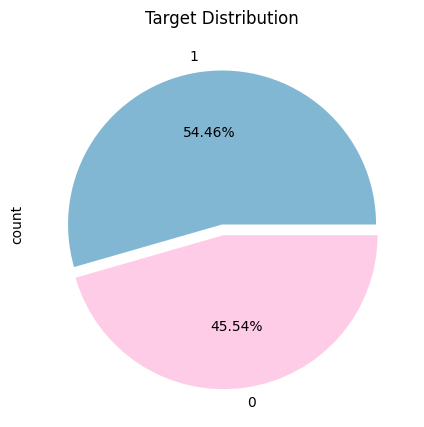

In [62]:
ax = df_copy['output'].value_counts().plot.pie(explode=[0,0.07],
                                               colors=["#81b7d2", "#ffcce7"],
                                               autopct='%.2f%%',
                                               figsize=(15, 5))
ax.set_title('Target Distribution');

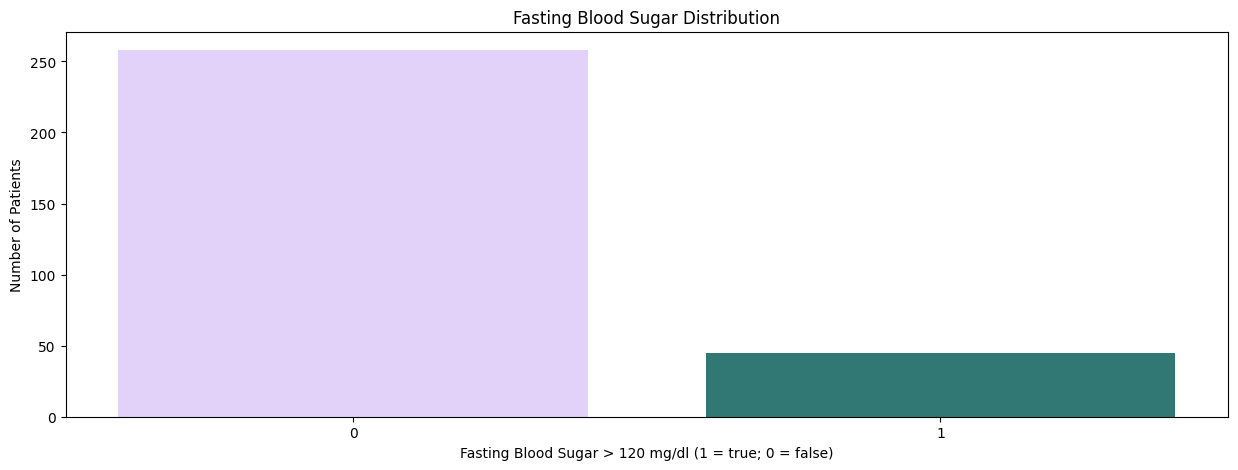

In [63]:
fbs_count = df['fbs'].value_counts()
plt.figure(figsize=(15,5))
plt.bar(fbs_count.index, fbs_count.values, color=["#E2D1F9", "#317773"])
plt.title('Fasting Blood Sugar Distribution')
plt.xlabel('Fasting Blood Sugar > 120 mg/dl (1 = true; 0 = false)')
plt.ylabel('Number of Patients')
plt.xticks(fbs_count.index)
plt.show()

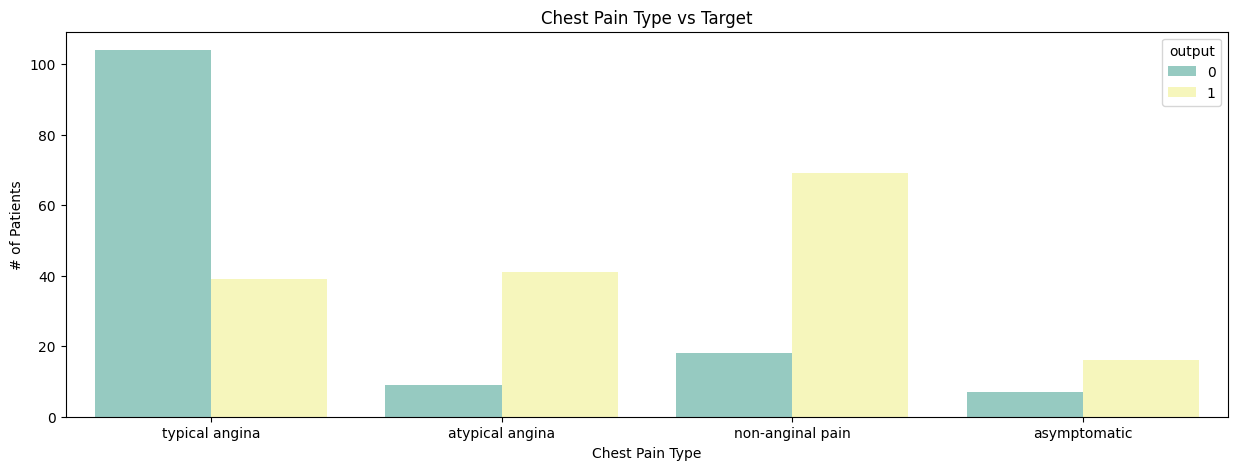

In [64]:
plt.figure(figsize=(15,5))
sns.countplot(data=df_copy,
              x='cp',
              hue='output',
              palette="Set3")
plt.title('Chest Pain Type vs Target');
plt.xlabel('Chest Pain Type')
plt.ylabel('# of Patients')
plt.xticks(ticks=[0,1,2,3],
           labels=['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'], rotation=0);

### Exporting Correlation Matrix

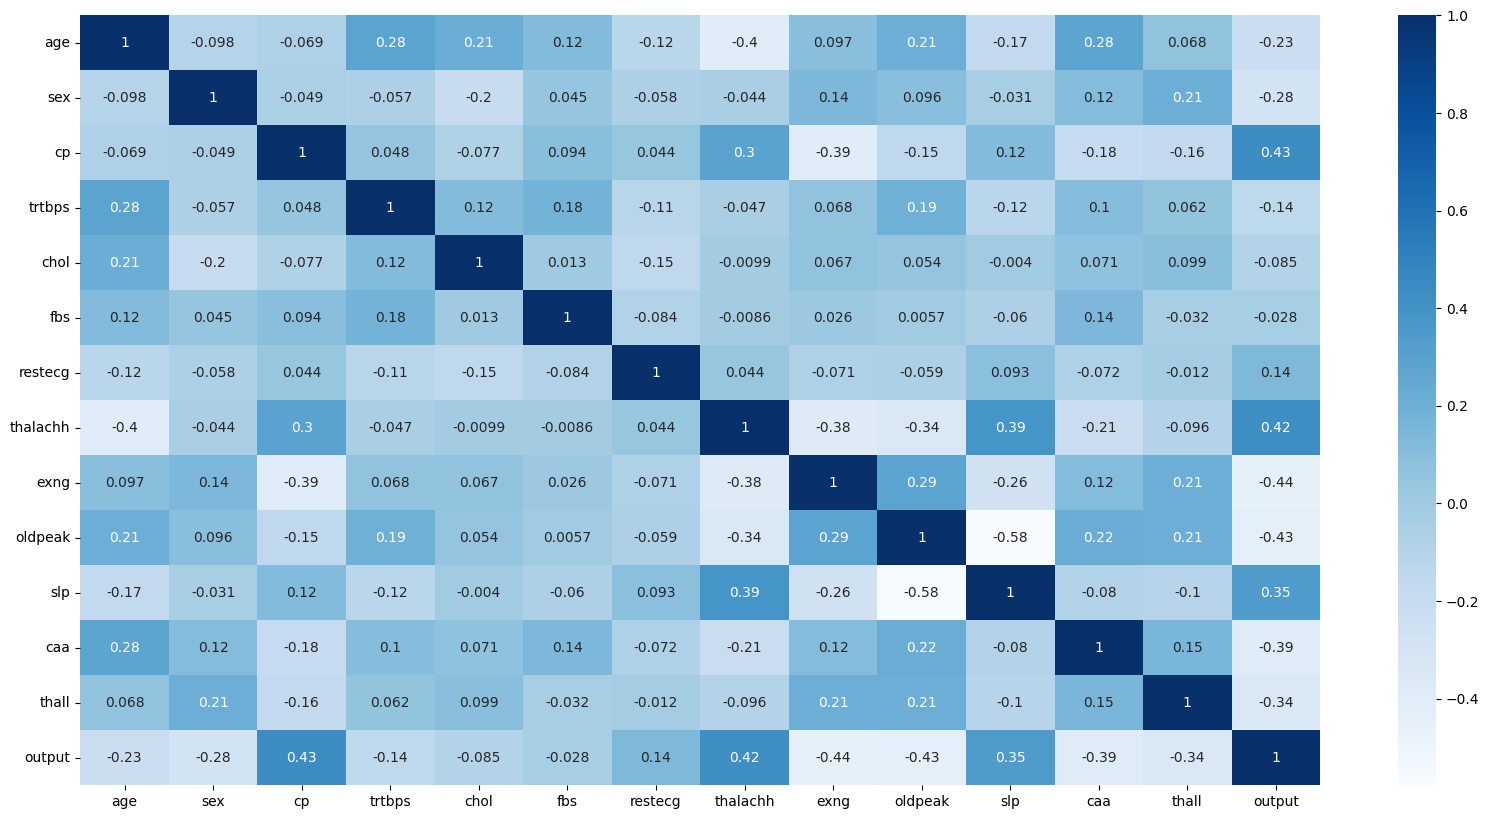

In [65]:
corr = df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, cmap="Blues", annot=True);

<a id="section-three"></a>
# **Feature Engineering**

<a id="section-four"></a>
## I. Missing Values

In [66]:
print(pd.concat([df_copy.isnull().sum(), df_copy.isnull().sum()/len(df_copy)*100],
                 keys=['Number of Missing Values', 'Ratio of Missing Values'],
                 axis=1))

          Number of Missing Values  Ratio of Missing Values
age                              0                     0.00
sex                              0                     0.00
cp                               0                     0.00
trtbps                           0                     0.00
chol                             0                     0.00
fbs                              0                     0.00
restecg                          0                     0.00
thalachh                         0                     0.00
exng                             0                     0.00
oldpeak                          0                     0.00
slp                              0                     0.00
caa                              0                     0.00
thall                            0                     0.00
output                           0                     0.00


<a id="section-five"></a>
## II. Outlier Detection and Handling

In [67]:
def outlier_thresholds(df, col_name, low_quantile=0.25, up_quantile=0.75):
    Q1 = df[col_name].quantile(low_quantile)
    Q3 = df[col_name].quantile(up_quantile)
    IQR = Q3 - Q1
    low_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR
    return low_limit, up_limit

In [68]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [69]:
for col in num_cols:
    print(col, check_outlier(df_copy, col))

age False
trtbps True
chol True
thalachh True
oldpeak True


C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\601142799.py:20: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(y="chol", data=df_copy, inner="quartile", bw=0.2)


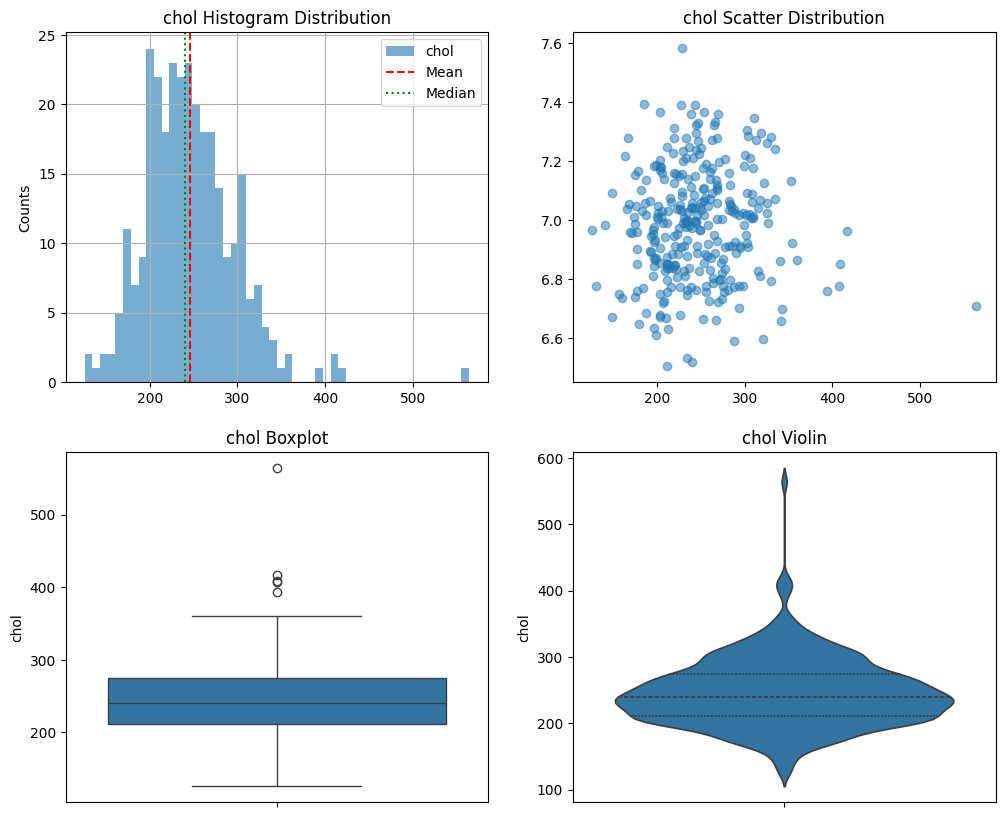

In [70]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
df_copy['chol'].hist(bins=50, label='chol', alpha=0.6)
plt.axvline(np.mean(df_copy['chol']), ls='--', c='r', label="Mean")
plt.axvline(np.median(df_copy['chol']), ls=':', c='g', label="Median")
plt.ylabel("Counts")
plt.title("chol Histogram Distribution");
plt.legend()

plt.subplot(2, 2, 2)
plt.scatter(df_copy['chol'], np.random.normal(7, 0.2, size=df_copy.shape[0]), alpha=0.5)
plt.title("chol Scatter Distribution");

plt.subplot(2, 2, 3)
sns.boxplot(y="chol", data=df_copy)
plt.title("chol Boxplot");

plt.subplot(2, 2, 4)
sns.violinplot(y="chol", data=df_copy, inner="quartile", bw=0.2)
plt.title("chol Violin");


In [71]:
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [72]:
for col in num_cols:
    print(col, replace_with_thresholds(df_copy, col))

age None
trtbps None
chol None
thalachh None
oldpeak None


C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\130684917.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '27.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\130684917.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '115.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\130684917.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '84.75' has dtype incompatible with int64, please explicitly cast to a compatible

C:\Users\pavan\AppData\Local\Temp\ipykernel_19020\3107035995.py:20: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(y="chol", data=df_copy, inner="quartile", bw=0.2)


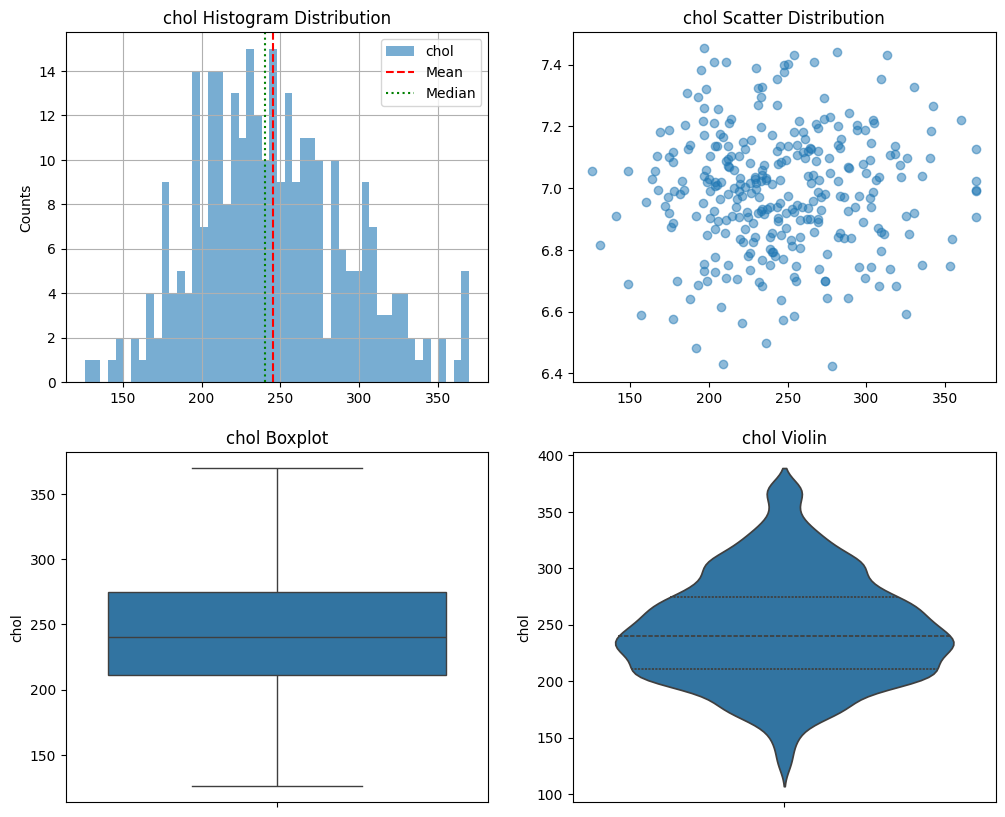

In [73]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
df_copy['chol'].hist(bins=50, label='chol', alpha=0.6)
plt.axvline(np.mean(df_copy['chol']), ls='--', c='r', label="Mean")
plt.axvline(np.median(df_copy['chol']), ls=':', c='g', label="Median")
plt.ylabel("Counts")
plt.title("chol Histogram Distribution");
plt.legend()

plt.subplot(2, 2, 2)
plt.scatter(df_copy['chol'], np.random.normal(7, 0.2, size=df_copy.shape[0]), alpha=0.5)
plt.title("chol Scatter Distribution");

plt.subplot(2, 2, 3)
sns.boxplot(y="chol", data=df_copy)
plt.title("chol Boxplot");

plt.subplot(2, 2, 4)
sns.violinplot(y="chol", data=df_copy, inner="quartile", bw=0.2)
plt.title("chol Violin");

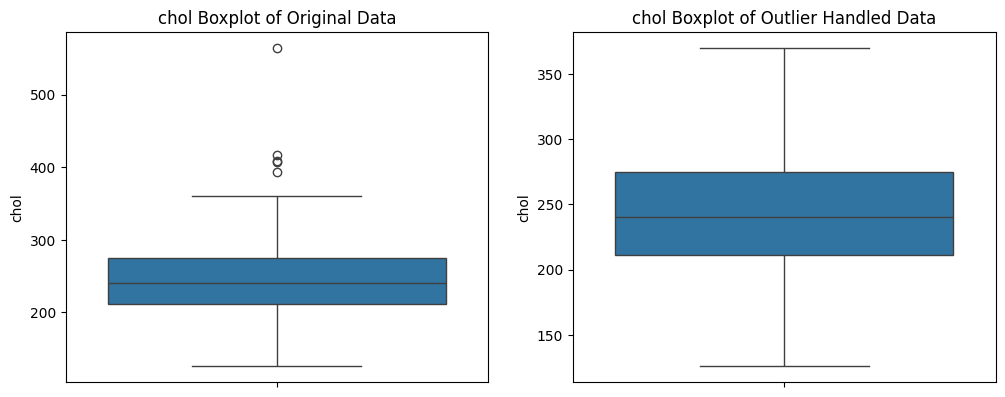

In [74]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.boxplot(y="chol", data=df)
plt.title("chol Boxplot of Original Data");

plt.subplot(2, 2, 2)
sns.boxplot(y="chol", data=df_copy)
plt.title("chol Boxplot of Outlier Handled Data");

<a id="section-six"></a>
## III. Feature Extraction

In [75]:
df_copy['Age_CAT'] = pd.cut(x=df_copy['age'],
                            bins=[20, 40, 60, df_copy['age'].max()],
                            labels=["Adult", "Middle_Age_Adult", "Senior_Adult"])

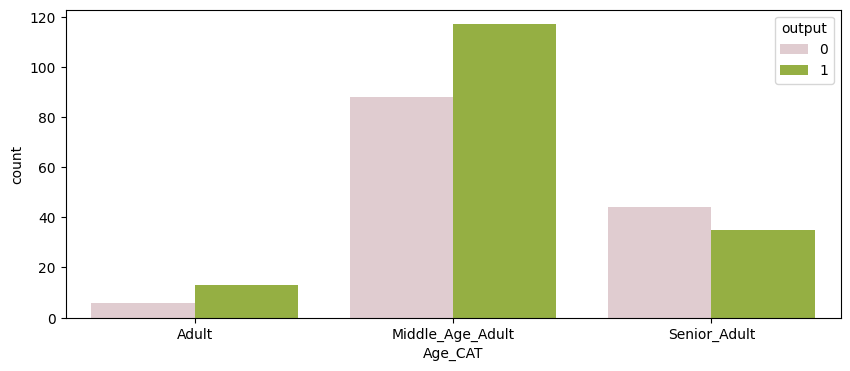

In [76]:
plt.figure(figsize=(10,4))
sns.countplot(data=df_copy, x='Age_CAT',
              hue='output',
              order=["Adult", "Middle_Age_Adult", "Senior_Adult"],
              palette=["#E3C9CEFF", "#9FC131FF"])
plt.show()

In [77]:
cat_cols.append('Age_CAT')
cat_cols

['sex',
 'cp',
 'fbs',
 'restecg',
 'exng',
 'slp',
 'caa',
 'thall',
 'output',
 'Age_CAT']

<a id="section-seven"></a>
## IV. Encoding and Scaling

In [78]:
def one_hot_encoder(dataframe, categorical_col, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_col, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df_copy.columns if 12 >= df_copy[col].nunique() > 2]
df_copy = one_hot_encoder(df_copy, ohe_cols, drop_first=True)

In [79]:
scaler = StandardScaler()
df_copy[num_cols] = scaler.fit_transform(df_copy[num_cols])

<a id="section-eight"></a>
# **Model Training**

In [80]:
y = df_copy["output"]
X = df_copy.drop("output", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [81]:
print('Shape of x_train is {}'.format(X_train.shape))
print('Shape of x_test is {}'.format(X_test.shape))
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

Shape of x_train is (242, 24)
Shape of x_test is (61, 24)
Shape of y_train is (242,)
Shape of y_test is (61,)


In [82]:
# -------------------------
# Compare multiple models and pick the best one by ROC-AUC
# -------------------------
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = [
    ('Logistic Regression', LogisticRegression(random_state=17, solver='lbfgs', max_iter=3000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=17)),
    ('Random Forest', RandomForestClassifier(random_state=17)),
    ('XGBoost', XGBClassifier(random_state=17, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(random_state=17, verbose=-1)),
    ('CatBoost', CatBoostClassifier(random_state=17, verbose=False))
]

best_model = None
best_name = None
best_score = -1

print("Evaluating models with 10-fold cross validation (ROC-AUC):\n")
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='roc_auc')
    mean_score = np.mean(scores)
    print(f"{name}: Mean ROC-AUC = {mean_score:.4f}")
    if mean_score > best_score:
        best_score = mean_score
        best_name = name
        best_model = model

print("\n✅ Best model selected:", best_name, f"(ROC-AUC: {best_score:.4f})")


Evaluating models with 10-fold cross validation (ROC-AUC):

Logistic Regression: Mean ROC-AUC = 0.9064
Decision Tree: Mean ROC-AUC = 0.7551
Random Forest: Mean ROC-AUC = 0.8807
XGBoost: Mean ROC-AUC = 0.8695
LightGBM: Mean ROC-AUC = 0.8716
CatBoost: Mean ROC-AUC = 0.9018

✅ Best model selected: Logistic Regression (ROC-AUC: 0.9064)


In [93]:
# -----------------------
# Rebuild a fully sklearn-compatible pipeline (no custom function) and save it
# -----------------------
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1) Find raw training dataframe rows that correspond to X_train
raw_df = None
for cand in ['df', 'df_copy', 'data', 'raw_df', 'df_raw', 'original_df']:
    if cand in globals():
        raw_df = globals()[cand]
        raw_name = cand
        break

if raw_df is None:
    raise RuntimeError("Cannot find raw dataframe in memory (df / df_copy). Re-run the data-loading cells first.")

# Align raw_train by index (preferred)
try:
    raw_train = raw_df.loc[X_train.index].drop(columns=['output'], errors='ignore')
except Exception:
    raw_train = raw_df.reset_index(drop=True).iloc[X_train.reset_index(drop=True).index].drop(columns=['output'], errors='ignore')

# 2) Determine numeric and categorical columns (use your existing lists if present)
try:
    numeric_cols = num_cols[:]   # from notebook
except NameError:
    # fallback: infer numeric columns from raw_train
    numeric_cols = raw_train.select_dtypes(include=["int64","float64"]).columns.tolist()

try:
    categorical_cols = ohe_cols[:]  # from notebook (these are the columns you used for one-hot)
except NameError:
    # fallback: treat non-numeric as categorical
    categorical_cols = [c for c in raw_train.columns if c not in numeric_cols]

# Filter categorical_cols to those actually present in raw_train
categorical_cols = [c for c in categorical_cols if c in raw_train.columns]

print("Numeric cols:", numeric_cols)
print("Categorical cols (to OHE):", categorical_cols)

# 3) Fit sklearn transformers on raw_train
scaler = StandardScaler().fit(raw_train[numeric_cols]) if len(numeric_cols) else None
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(raw_train[categorical_cols]) if len(categorical_cols) else None


# 4) Build ColumnTransformer (use fitted transformers)
transformers = []
if scaler is not None:
    transformers.append(('num', scaler, numeric_cols))
if ohe is not None:
    transformers.append(('cat', ohe, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Fit the ColumnTransformer on raw_train so it is ready (fit happens inside .fit on transformer)
# Note: we already fitted scaler and ohe individually above to be safe, but ColumnTransformer
# should also be fitted to set up internal state - we'll fit it on raw_train.
preprocessor = preprocessor.fit(raw_train)

# 5) Create final pipeline with the already-trained estimator (best_model)
# Important: best_model must already be trained (it was trained earlier). We DO NOT call pipeline.fit()
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),   # fitted ColumnTransformer
    ('model', best_model)             # estimator already fitted earlier in notebook
])

# 6) Save the final pipeline
with open('model_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

print("✅ Rebuilt and saved sklearn-only pipeline as model_pipeline.pkl")

# 7) Quick sanity test on the raw_test rows (if raw_df and X_test exist)
try:
    raw_test = raw_df.loc[X_test.index].drop(columns=['output'], errors='ignore')
    pipe = pickle.load(open('model_pipeline.pkl','rb'))
    preds = pipe.predict(raw_test)
    print("Sanity check predictions (first 5):", preds[:5])
except Exception as e:
    print("Sanity test failed:", e)


Numeric cols: ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
Categorical cols (to OHE): ['cp', 'restecg', 'slp', 'caa', 'thall']
✅ Rebuilt and saved sklearn-only pipeline as model_pipeline.pkl
Sanity check predictions (first 5): [0 1 0 0 1]


In [87]:
# Evaluate pipeline on the RAW test rows that correspond to X_test
import pickle
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

pipe = pickle.load(open('model_pipeline.pkl','rb'))

# Try to build raw_test (the raw dataframe rows corresponding to X_test)
raw_df = None
for cand in ['df', 'data', 'raw_df', 'df_raw', 'original_df', 'df_copy_original']:
    if cand in globals():
        raw_df = globals()[cand]
        raw_name = cand
        break

if raw_df is None:
    raise RuntimeError("Can't find original raw dataframe in memory. Look for variable named 'df' or 'raw_df'. Re-run the notebook cells that load the CSV into a DataFrame and name it 'df'.")

# Now try to select rows corresponding to X_test
try:
    # Preferred: use same indices (train_test_split preserves original indices)
    raw_test = raw_df.loc[X_test.index].drop(columns=['output'], errors='ignore')
except Exception:
    # Fallback: if indices don't match, try positional selection using integer locations
    try:
        raw_test = raw_df.reset_index(drop=True).iloc[X_test.reset_index(drop=True).index].drop(columns=['output'], errors='ignore')
    except Exception as e:
        raise RuntimeError("Failed to align raw rows to X_test. Paste the outputs of `raw_df.shape` and `X_test.shape` here so I can help.") from e

# Now predict and report metrics
y_pred = pipe.predict(raw_test)
y_proba = pipe.predict_proba(raw_test)[:,1] if hasattr(pipe, "predict_proba") else None

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
if y_proba is not None:
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9016
ROC-AUC: 0.9407

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Confusion matrix:
 [[27  2]
 [ 4 28]]


In [47]:
import pandas as pd, pickle
pipe = pickle.load(open('model_pipeline.pkl','rb'))

sample = {
  'age':52,'sex':1,'cp':2,'trtbps':130,'chol':250,
  'fbs':0,'restecg':1,'thalachh':160,'exng':0,
  'oldpeak':1.5,'slp':2,'caa':0,'thall':2
}
sample_df = pd.DataFrame([sample])
print("Pred:", int(pipe.predict(sample_df)[0]))
print("Prob:", float(pipe.predict_proba(sample_df)[0][1]))


Pred: 0
Prob: 0.4131278882384406


In [88]:
import pandas as pd, pickle
pipe = pickle.load(open('model_pipeline.pkl','rb'))
raw_test = raw_df.loc[X_test.index].drop(columns=['output'], errors='ignore')  # raw_df is your original df variable
preds = pipe.predict(raw_test)
probs = pipe.predict_proba(raw_test)[:,1] if hasattr(pipe, "predict_proba") else [None]*len(preds)
out = raw_test.copy()
out['y_true'] = y_test.values
out['y_pred'] = preds
out['y_proba'] = probs
out.to_csv('test_predictions.csv', index=False)
print("Saved test_predictions.csv")


Saved test_predictions.csv


In [89]:
import pandas as pd, pickle
pipe = pickle.load(open('model_pipeline.pkl','rb'))
sample = {'age':52,'sex':1,'cp':2,'trtbps':130,'chol':250,'fbs':0,'restecg':1,'thalachh':160,'exng':0,'oldpeak':1.5,'slp':2,'caa':0,'thall':2}
print(pipe.predict(pd.DataFrame([sample]))[0])
print(pipe.predict_proba(pd.DataFrame([sample]))[0][1])


0
0.42363714854997186
